# Функция
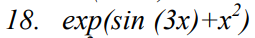

### Задание 1
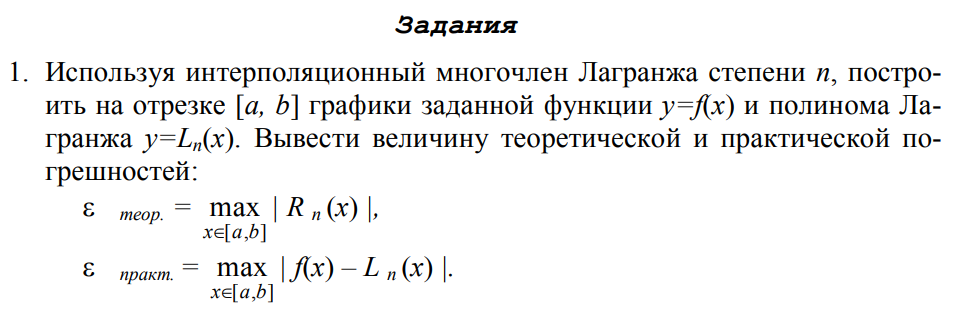

Практическая погрешность: 0.000444154291790122
Теоретическя погрешность: 0.0018160808496357431


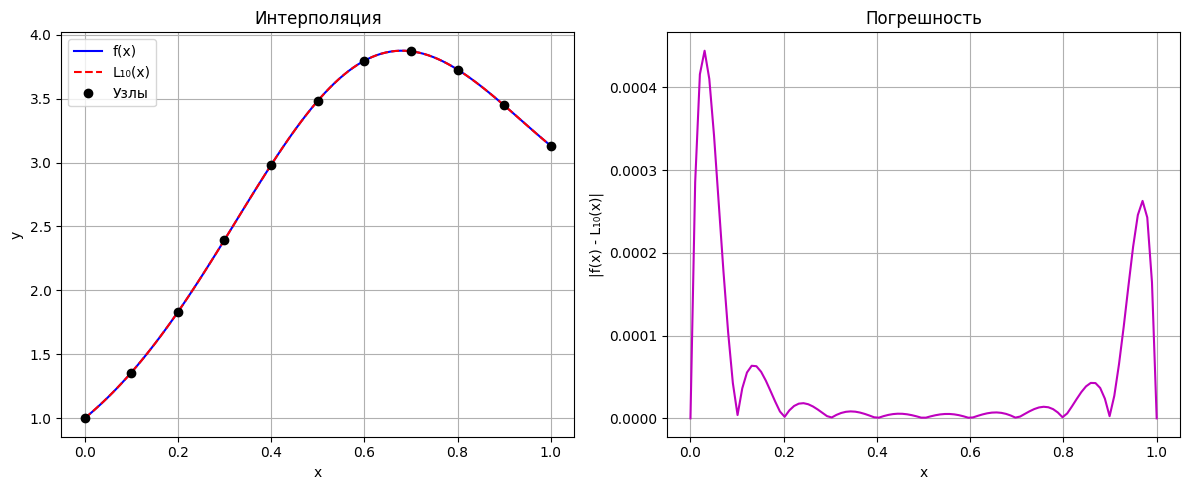

In [23]:
import math
import matplotlib.pyplot as plt

def f(x):
    return math.exp(math.sin(3*x)+ x*x)


def linspace(a,b,n):
    """Возвращает n точек на промежутке [a,b]"""
    
    if n==1:
        return[a]
    
    step = (b - a) / (n - 1)
    return [a + i * step for i in range(n)]


def lagrange_interpolate(x_eval_list, x_nodes, y_nodes):
    """
    x_eval_list - массив точек  
    x_nodes - узлы интерполяции (n+1 массив)  
    y_nodes - значения f(x) в узлах (n+1 массив)  
    Возвращает список значений Ln(x)
    """
    
    n = len(x_nodes)
    result = []
    
    for x in x_eval_list:
        total = 0.0
        for i in range(n):
            num = 1.0
            den = 1.0
            for j in range(n):
                if i != j:
                    num *= (x - x_nodes[j])
                    den *= (x_nodes[i] - x_nodes[j])
            
            if den == 0:
                li = 0.0
            else:
                li = num / den
            total += y_nodes[i] * li
        result.append(total)    
    return result


def abs_list(list):
    """Абсолютное значение"""
    return [abs(x) for x in list]


def max_list(list):
    """Максимальное значение"""
    return max(list)


def factorial(n):
    """Факториал"""
    if n < 0:
        raise ValueError("Нельзя вычислить факториал отр. числа")
    
    result = 1
    for i in range(2,n + 1):
        result *= i
    return result


def omega_at(x, x_nodes):
    prod = 1.0
    for xi in x_nodes:
        prod *= (x - xi)
    return prod


def omega_list(x_list, x_nodes):
    """Вычисление omega(x)"""
    return [omega_at(x, x_nodes) for x in x_list]

def numerical_derivative_n(func, x, order, h=0.001):
    """Рекурсивное вычисление производной n-го порядка"""
    if order == 0:
        return func(x)
    val_plus = numerical_derivative_n(func, x + h, order - 1, h)
    val_minus = numerical_derivative_n(func, x - h, order - 1, h)
    return (val_plus - val_minus) / (2 * h)


def main():
    a,b = 0.0, 1.0
    n_degree = 10
    n_nodes = n_degree + 1
    
    # Узлы
    x_nodes = linspace(a, b, n_nodes)
    y_nodes = [f(x) for x in x_nodes]
    
    # Сетка
    n_fine = 100
    x_fine = linspace(a, b, n_fine)
    f_true = [f(x) for x in x_fine]
    
    # Интерполянт
    f_interpolate = lagrange_interpolate(x_fine, x_nodes, y_nodes)
    
    # Практическая погрешность
    errors = [abs(f_true[i] - f_interpolate[i]) for i in range(len(x_fine))]
    eps_practical = max_list(errors)
    
    # Оценка omega(x)
    omega_vals = abs_list(omega_list(x_fine,x_nodes))
    max_omega = max(omega_vals)
    
    # Теоретическая погрешность
    max_deriv = 0.0
    for x_val in x_fine:
        d_val = abs(numerical_derivative_n(f, x_val, n_degree + 1, h=0.005))
        if d_val > max_deriv:
            max_deriv = d_val
    
    factorial_n1 = factorial(n_degree + 1)
    eps_theoretical = (max_deriv / factorial_n1) * max_omega
    
    print(f"Практическая погрешность: {eps_practical}")
    print(f"Теоретическя погрешность: {eps_theoretical}")
    
    plt.figure(figsize=(12, 5))

    # График функции и интерполянта
    plt.subplot(1, 2, 1)
    plt.plot(x_fine, f_true, 'b-', label='f(x)')
    plt.plot(x_fine, f_interpolate, 'r--', label='L₁₀(x)')
    plt.plot(x_nodes, y_nodes, 'ko', label='Узлы')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Интерполяция')
    plt.legend()
    plt.grid(True)

    # График погрешности
    plt.subplot(1, 2, 2)
    plt.plot(x_fine, errors, 'm-')
    plt.xlabel('x')
    plt.ylabel('|f(x) - L₁₀(x)|')
    plt.title('Погрешность')
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
if __name__ == "__main__":
    main()
    


### Задание 2
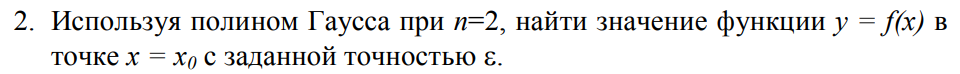

In [64]:
import math


def f(x):
    return math.exp(math.sin(3*x)+ x*x)


def nearest_nodes(x, x_grid):
    """Возвращает j, x_grid[j-1], x_grid[j], x_grid[j+1] - узлы близжайшие к x"""
    n = len(x_grid)
    j = min(range(n), key=lambda i: abs(x_grid[i] - x))
    
    if j == 0:
        j = 1
    elif j == n - 1:
        j = n-2
        
    return j, x_grid[j-1], x_grid[j], x_grid[j+1]

def get_M3_on_interval(func, a, b, steps=100):
    """
    Ищет максимум модуля 3-й производной на отрезке [a,b]
    """
    max_val = 0.0
    step = (b - a) / steps
    
    x = a
    for _ in range(steps + 1):
        deriv_val = abs(numerical_derivative_n(func, x, order=3, h=0.005))
        
        if deriv_val > max_val:
            max_val = deriv_val
        x += step
        
    return max_val


def gauss_interpolation(x0, x_grid, epsilon = 1e-6):
    """
    Вычисляет f(x0)  
    Подбирает шаг h до достижения точноси епсилон  
    """
    h = 0.5
    max_iterations = 100
    
    for iter in range(max_iterations):
        a,b = 0.0, 1.0
        n = int((b-a) / h) + 1
        x_grid = [a + i * h for i in range(n)]
        
        # Близжайщие узлы к x0
        j, x_prev, x_curr, x_next = nearest_nodes(x0,x_grid)

        # Значения функции
        y_prev = f(x_prev)
        y_curr = f(x_curr)
        y_next = f(x_next)
        
        # Конечные разности
        y1_half = y_next - y_curr
        y2_j = y_prev - 2*y_curr + y_next
        
        t = (x0 - x_curr) / h
        
        approx = y_curr + y1_half * t + y2_j * t * (t-1) / 2.0
        
        true_val = f(x0)
        error = abs(true_val - approx)
        
        # Оценка теоретической погрешности
        M3 = get_M3_on_interval(f, x_prev, x_next)

        reminder_bound = M3 * (h**3) * abs(t * (t*t - 1)) / 6.0
        print(f"Шаг h = {h:.6f} | Теоретическая {reminder_bound:.10f} | Практическая {error:.10f}")
        
        if error < epsilon:
            print(f"\nТочность: {epsilon}, при h = {h:.10f}")
            return approx, error, h, reminder_bound
        
        h /= 2.0
        
        if h < 1e-8:
            break
        

if __name__ == "__main__":
    x0 = 0.3
    epsilon = 1e-6
    
    result, err, final_h, reminder_bound = gauss_interpolation(x0, None, epsilon)
    print(f"Результат при x0 = {x0}: {result:.10f}")
    print(f"Практическая погрешность: {err:.10f}")
    print(f"Теоретическая погрешность: {reminder_bound:.10f}")


Шаг h = 0.500000 | Теоретическая 0.8179473526 | Практическая 0.4340550622
Шаг h = 0.250000 | Теоретическая 0.0584248109 | Практическая 0.0366289074
Шаг h = 0.125000 | Теоретическая 0.0126023465 | Практическая 0.0083094357
Шаг h = 0.062500 | Теоретическая 0.0009001676 | Практическая 0.0007574613
Шаг h = 0.031250 | Теоретическая 0.0001861338 | Практическая 0.0001664115
Шаг h = 0.015625 | Теоретическая 0.0000120467 | Практическая 0.0000113225
Шаг h = 0.007812 | Теоретическая 0.0000025538 | Практическая 0.0000024774
Шаг h = 0.003906 | Теоретическая 0.0000001824 | Практическая 0.0000001793

Точность: 1e-06, при h = 0.0039062500
Результат при x0 = 0.3: 2.3948652937
Практическая погрешность: 0.0000001793
Теоретическая погрешность: 0.0000001824
